In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
# Read the CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/TA/Proposal/data_diabetes.csv')

In [ ]:
# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

| Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI   | DiabetesPedigreeFunction   | Age   | Outcome   |
|:--------------|:----------|:----------------|:----------------|:----------|:------|:---------------------------|:------|:----------|
| 6             | 148       | 72              | 35              | 0         | 33.6  | 0.627                      | 50    | 1         |
| 1             | 85        | 66              | 29              | 0         | 26.6  | 0.351                      | 31    | 0         |
| 8             | 183       | 64              | 0               | 0         | 23.3  | 0.672                      | 32    | 1         |
| 1             | 89        | 66              | 23              | 94        | 28.1  | 0.167                      | 21    | 0         |
| 0             | 137       | 40              | 35              | 168       | 43.1  | 2.288                      | 33    | 1         |


In [ ]:
# Print the column names and their data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


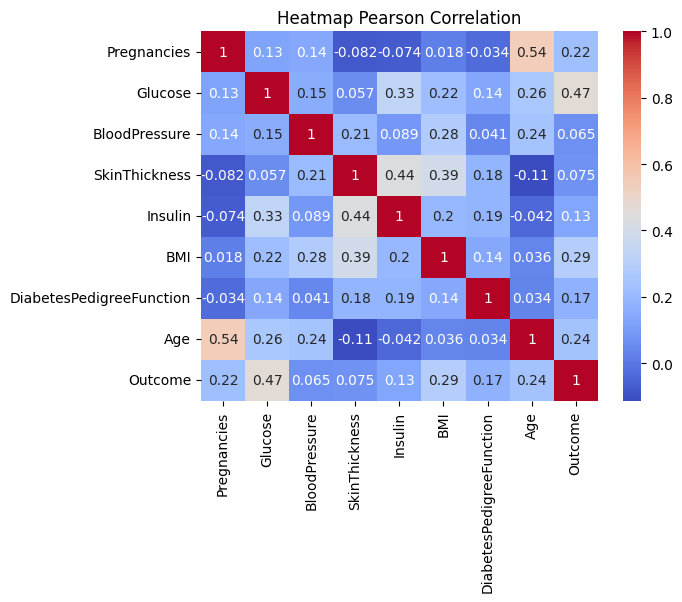

In [ ]:
# Melihat korelasi dengan Pearson Correlation
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap Pearson Correlation')
plt.show()

In [ ]:
### 1. Deteksi Missing Values ###
missing_values = df.isnull().sum()
print("\nMissing Values:\n", missing_values)

# Mengatasi missing values dengan imputasi median (bisa disesuaikan)
df.fillna(df.median(numeric_only=True), inplace=True)


Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


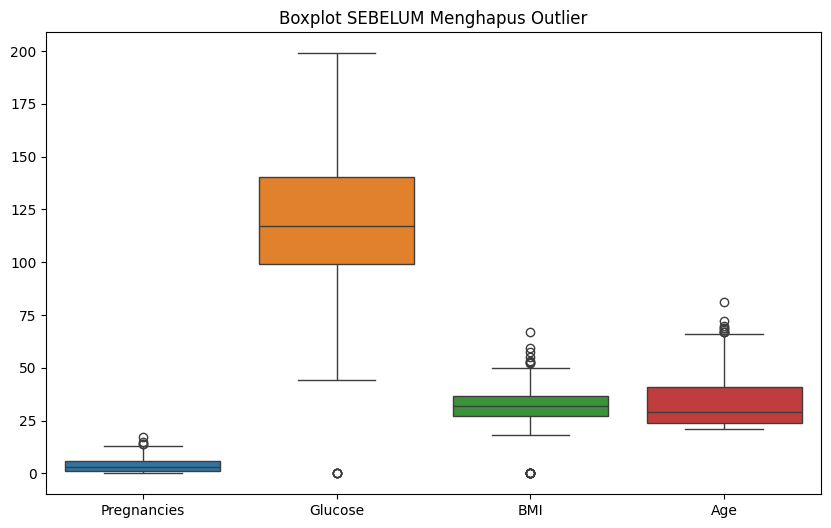

In [ ]:
### 2. Deteksi Outlier dengan Boxplot SEBELUM Menghapus ###
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Pregnancies', 'Glucose', 'BMI', 'Age']])
plt.title("Boxplot SEBELUM Menghapus Outlier")
plt.show()

In [ ]:
### Hapus Outlier yang Tidak Masuk Akal ###
# Menghapus baris dengan Glucose = 0 atau BMI = 0 karena ini tidak mungkin terjadi dalam konteks medis
df = df[(df['Glucose'] > 0) & (df['BMI'] > 0)]

print("\nJumlah data setelah menghapus outlier tidak masuk akal:", len(df))


Jumlah data setelah menghapus outlier tidak masuk akal: 752


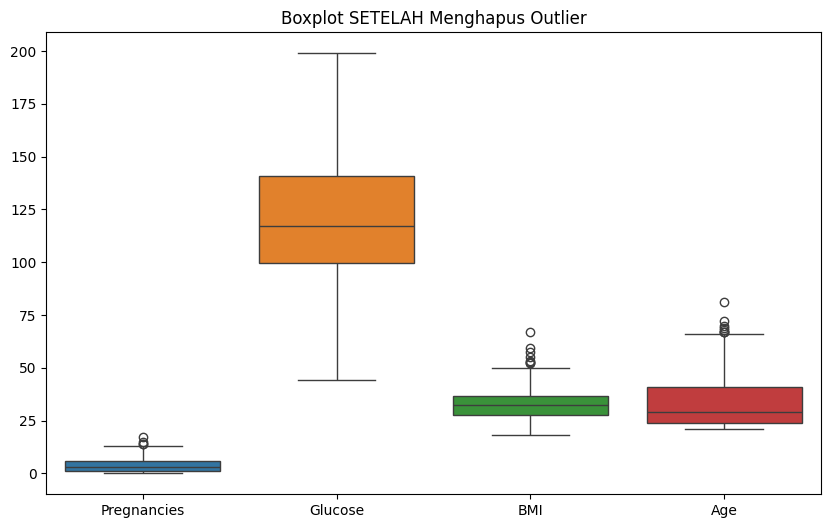

In [ ]:
### Deteksi Outlier dengan Boxplot SETELAH Menghapus ###
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Pregnancies', 'Glucose', 'BMI', 'Age']])
plt.title("Boxplot SETELAH Menghapus Outlier")
plt.show()

In [ ]:
# Memisahkan fitur dan target
X = df[['Pregnancies', 'Glucose', 'BMI', 'Age']]
y = df['Outcome']

In [ ]:
#Pembagian Data: Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 4. Inisialisasi Model
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# Melatih model dengan data training
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Prediksi hasil dengan data testing
y_pred = knn.predict(X_test)

In [ ]:
# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
# Menampilkan hasil evaluasi
print(f"\nAkurasi: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Akurasi: 0.8013
Precision: 0.7885
Recall: 0.6833
F1-score: 0.7321


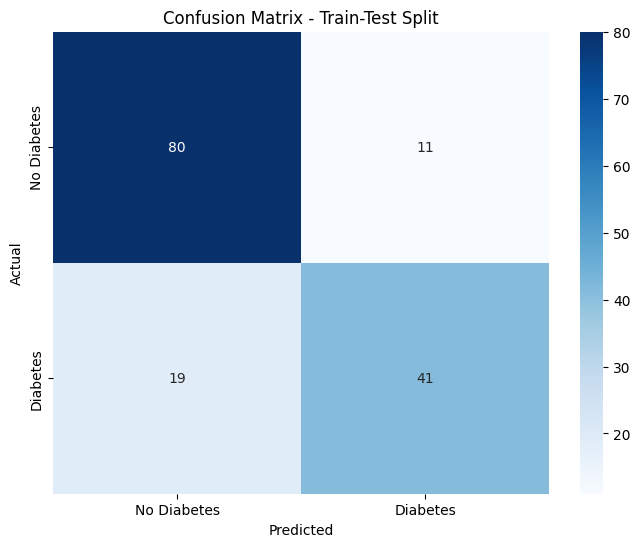

In [ ]:
# Menampilkan confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Train-Test Split')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()